In [5]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated, Literal, Optional

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_community.tools.tavily_search import TavilySearchResults

from dotenv import load_dotenv


In [2]:
load_dotenv()

True

In [3]:
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(...,
            description="One sentence describing what the reader should be able to do/understand after this section.")
    
    bullets: str = Field(..., 
            min_length=3,
            max_length=5,
            description="3-5 concrete, non-overlapping subpoints to cover in this section.")
    
    target_words: int = Field(..., 
            description="Target word count for this section(120-450).")
    
    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool  = False


In [7]:
class Plan(BaseModel):
    blog_title: str
    audience: str
    tone: str 
    blog_kind: Literal['explainer', 'tutorial', 'news_roundup', 'comparison', 'system_design'] = 'explainer'
    constraints: List[str] = Field(default_factory=list)
    tasks: List[Task]

class EvidenceItem(BaseModel):
    title: str
    url: str

    # optional means keep if tavily provides it don't rely on it
    published_at: Optional[str] = None
    snippet: Optional[str] = None
    source: Optional[str] = None

class RouterDecision(BaseModel):
    need_research: bool
    mode: Literal['closed_book', 'hybrid', 'open_book']
    queries: List[str] = Field(default_factory=list)

class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)


In [ ]:
class State(TypedDict):

    topic: str

    # routing/research
    mode: str
    need_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]
    
    # reducer: results from worker nodes get concatenated here automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [176]:
planner_llm = ChatGroq(
    model="qwen/qwen3.8-27b",
    temperature=0.0,
    max_tokens=1000
)

worker_llm = ChatGroq(model="openai/gpt-oss-20b",
    temperature=0.5,
    max_tokens=700)

In [177]:
# Use to make plan
def orchestrator(state: State) -> dict:

    plan = planner_llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=( "You are a senior technical writer and developer advocate. Your job is to produce a "
                    "highly actionable outline for a technical blog post.\n\n"
                    "Hard requirements:\n"
                    "- Create 5 sections (tasks) that fit a technical blog.\n"
                    "- Each section must include:\n"
                    "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
                    "  2) 3–5 bullets that are concrete, specific, and non-overlapping\n"
                    "  3) target word count (120–450)\n"
                    "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"
                    "Make it technical (not generic):\n"
                    "- Assume the reader is a developer; use correct terminology.\n"
                    "- Prefer design/engineering structure: problem → intuition → approach → implementation → "
                    "trade-offs → testing/observability → conclusion.\n"
                    "- Bullets must be actionable and testable (e.g., 'Show a minimal code snippet for X', "
                    "'Explain why Y fails under Z condition', 'Add a checklist for production readiness').\n"
                    "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
                    "  * a minimal working example (MWE) or code sketch\n"
                    "  * edge cases / failure modes\n"
                    "  * performance/cost considerations\n"
                    "  * security/privacy considerations (if relevant)\n"
                    "  * debugging tips / observability (logs, metrics, traces)\n"
                    "- Avoid vague bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what "
                    "to build/compare/measure/verify.\n\n"
                    "Ordering guidance:\n"
                    "- Start with a crisp intro and problem framing.\n"
                    "- Build core concepts before advanced details.\n"
                    "- Include one section for common mistakes and how to avoid them.\n"
                    "- End with a practical summary/checklist and next steps.\n\n"
                    "Output must strictly match the Plan schema." 
                )
            ),
            HumanMessage(content=f'Topic: {state['topic']}')
        ]
    )
    
    return {'plan':plan}

In [178]:
# simply check how many tasks or section are made 
def fanout(state: State):
    return [Send("worker", {'task': task, 'topic': state['topic'], 'plan':state['plan']})
            for task in state['plan'].tasks]
            

In [179]:
def worker(payload: dict)-> dict:

    task = payload['task']
    topic= payload['topic']
    plan = payload['plan']

    blog_title = plan.blog_title
    section_md = worker_llm.invoke(
        [
            SystemMessage(content=
                        "You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
                        "Hard constraints:\n"
                        "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
                        "- Stay close to the Target words (±15%).\n"
                        "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
                        "Technical quality bar:\n"
                        "- Be precise and implementation-oriented (developers should be able to apply it).\n"
                        "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
                        "- When relevant, include at least one of:\n"
                        "  * a small code snippet (minimal, correct, and idiomatic)\n"
                        "  * a tiny example input/output\n"
                        "  * a checklist of steps\n"
                        "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
                        "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
                        "- Call out edge cases / failure modes and what to do about them.\n"
                        "- If you mention a best practice, add the 'why' in one sentence.\n\n"
                        "Markdown style:\n"
                        "- Start with a '## <Section Title>' heading.\n"
                        "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
                        "- Avoid fluff. Avoid marketing language.\n"
                        "- If you include code, keep it focused on the bullet being addressed.\n"
                    ),
            HumanMessage(
                content=(
                    f'Blog: {blog_title}\n'
                    f'Audience: {plan.audience}\n'
                    f'Tone: {plan.tone}\n'
                    f'Topic: {topic}\n'
                    f'Section: {task.title}\n'
                    f'Section type: {task.section_type}\n'
                    f'Goal: {task.goal}\n'
                    f'Target words: {task.target_words}\n'
                    f'Bullets: {task.bullets}\n\n'
                )
            ),
        ]
    ).content.strip()

    print("WORKER RUNNING:", task.id)
    print("WORKER OUTPUT:", repr(section_md))

    return {"sections": [section_md]}


In [180]:
from pathlib import Path
import re

def reducer(state: State) -> dict:

    print("REDUCER RECEIVED SECTIONS:", len(state["sections"]))
    print("SECTIONS:", state["sections"])

    title = state['plan'].blog_title
    body = "\n\n".join(state['sections']).strip()

    final_md = f'# {title}\n\n{body}\n'

    # save to a file
    filename = re.sub(r'[<>:"/\\|?*]', '', title.lower())
    filename = filename.lower().replace(" ", "_")+".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    print("FILE SAVED:", output_path.resolve())
    return {"final": final_md}

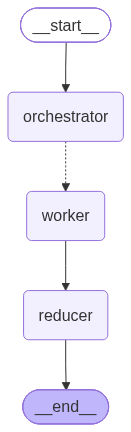

In [181]:
graph = StateGraph(State)
graph.add_node('orchestrator', orchestrator)
graph.add_node('worker', worker)
graph.add_node('reducer', reducer)

graph.add_edge(START, 'orchestrator')
graph.add_conditional_edges('orchestrator', fanout, ['worker'])
graph.add_edge('worker', 'reducer')
graph.add_edge('reducer', END)

app = graph.compile()

app

In [184]:
out = app.invoke({'topic': "write a blog on openAI", 'sections': []})


WORKER RUNNING: 1
WORKER OUTPUT: ''
WORKER RUNNING: 5
WORKER OUTPUT: '## Production Readiness Checklist and Next Steps\n\nBelow is a concise, testable checklist you can run against your OpenAI integration before lifting the production flag. Each item includes a quick sanity test or code snippet to confirm compliance.\n\n| # | Item | Quick Test / Code |\n|---|------|-------------------|\n| 1 | **API Key Management** | Verify secrets are stored in a vault (e.g., AWS Secrets Manager) and not in source control. |\n| 2 | **Rate Limiting & Throttling** | Ensure your client respects the model’s `max_tokens` and `max_retries`. |\n| 3 | **Retry Logic** | Implement exponential back‑off for transient errors (`429`, `502`). |\n| 4 | **Logging & Observability** | Log request IDs, latency, and error codes. |\n| 5 | **Monitoring** | Set up alerts for high latency, error rates, and quota exhaustion. |\n| 6 | **Security** | Use HTTPS, validate request payloads, and enforce least‑privilege on API keys. 

In [183]:
print(out)

{'topic': 'write a blog on openAI', 'plan': Plan(blog_title="Building Production-Ready Applications with OpenAI's API: A Practical Guide", audience='Backend and full-stack developers integrating LLMs into production systems', tone='Practical, direct, and code-focused', tasks=[Task(id=1, title='Why Naive OpenAI Integrations Fail in Production', goal="The reader understands the specific engineering challenges of integrating OpenAI's API into a production system and what this post will cover.", bullets='State', target_words=150, section_type='intro'), Task(id=2, title='Core Integration: A Resilient API Client', goal='The reader can implement a robust, retryable OpenAI API client with proper error handling and cost tracking.', bullets='Show', target_words=350, section_type='core'), Task(id=3, title='Common Mistakes and How to Avoid Them', goal='The reader can identify and fix the most common failure modes in OpenAI integrations before they hit production.', bullets='Demon', target_words=30